# Algotytm przecinania się odcinków na płaszczyźnie

In [1]:
import numpy as np
import pandas as pd
from bitalg.tests.test4 import Test
from bitalg.visualizer.main import Visualizer
import math
import random

# Przydatne funkcje 

In [2]:
def draw_example_1():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))

    vis.add_line_segment(line_segments)
    vis.show()
    
def draw_example_2():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))
    points = [(4, 2),
              (2.5, 3.5),
              (5.5, 4.5)]

    vis.add_line_segment(line_segments)
    vis.add_point(points, color='red')
    vis.show()


### Wprowadzenie
Celem ćwiczenia jest implementacja i zapoznanie się z algorytmem wyznaczającym wszystkie przecięcia się odcinków na płaszczyźnie

### Przykładowy zbiór odcinków przed wyznaczeniem punktów przecięcia

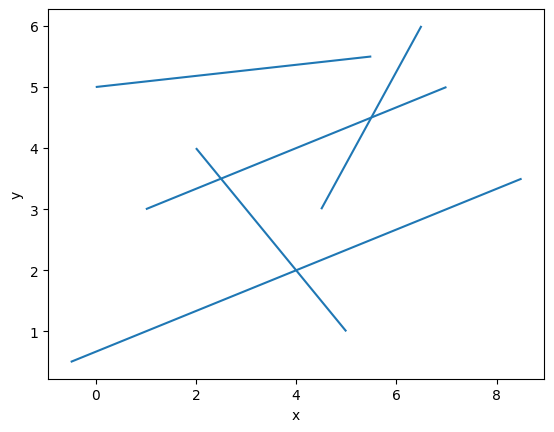

In [3]:
draw_example_1()

### Przykładowy zbiór odcinków po wyznaczenu punktów przecięcia

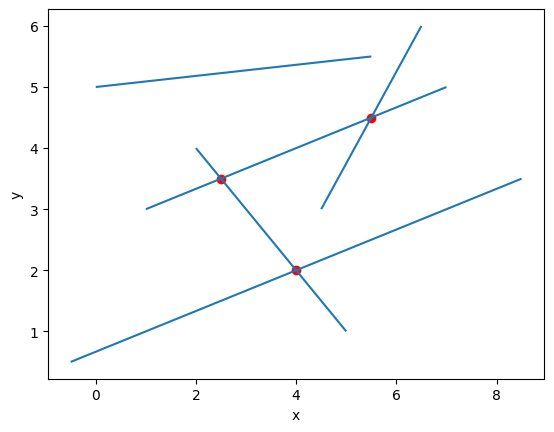

In [4]:
draw_example_2()

# Generowanie losowych odcinków na płaszczyźnie

Uzupełnij funkcję ```generate_uniform_sections```

In [5]:
def generate_uniform_sections(max_x, max_y, n):
    """
    Funkcja generuje odcinki o współrzędnych rzeczywistych w postaci par punktów. 
    Żaden wygenerowany odcinek nie jest odcinkiem pionowym.
    Żadne dwa odcinki nie mają swoich końców o takiej samej współrzędnej x.
    Zakres współrzędnych: x -> (0, max_x), y -> (0, max_y)
    :param max_x: określa maksymalną wartość współrzednej x jaka może zostać wylosowana
    :param max_y: określa maksymalną wartość współrzednej y jaka może zostać wylosowana
    :param n: ilość generowanych odcinków
    :return: tablica odcinków w postaci krotek zawierających parę krotek współrzędnych punktów końcowych odcinków
    np. [((x1, y1), (x2, y2)), ((x3, y3), (x4, y4)),...]
    """
    unique_x = set()
    while len(unique_x) < 2 * n:
        unique_x.add(random.uniform(0, max_x))
    
    x_coords = list(unique_x)
    random.shuffle(x_coords)
    
    segments = []
    
    for i in range(n):
        x1 = x_coords[2 * i]
        x2 = x_coords[2 * i + 1]
        
        y1 = random.uniform(0, max_y)
        y2 = random.uniform(0, max_y)
        
        segment = ((x1, y1), (x2, y2))
        segments.append(segment)
        
    return segments

In [6]:
Test().runtest(1, generate_uniform_sections)

Lab 4, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.119s


<span style="color:red">Ćw.</span> Wygeneruj $\large20$ losowych odcinków w przestrzeni 2D o współrzędnych z przedziału $\large x \in \langle 0,1000 \rangle$ oraz $\large y \in \langle 0,1000\rangle$. 

In [7]:
section = generate_uniform_sections(1000, 1000, 20)

Zwizualizuj otrzymane odcinki

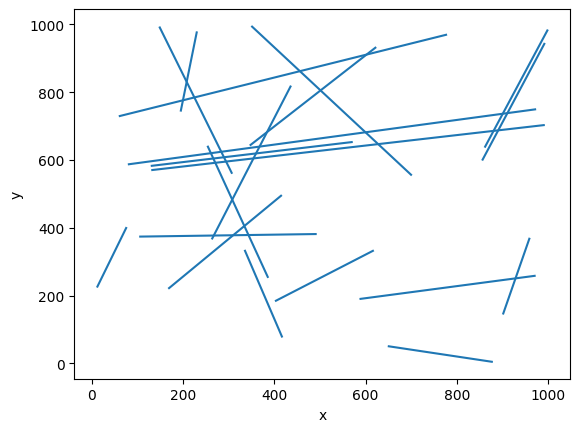

In [8]:
vis = Visualizer()
vis.add_line_segment(section)
vis.show()

Uzupełnij funkcję ```add_sections``` #interaktywne dodawanie odcinków przez rysowanie myszką

In [9]:
def add_sections(sections):
    vis = Visualizer()
    vis.add_line_segment(sections)
    vis.show()

In [10]:
class peakType:
    START = 0
    INTERSECTION = 1
    END = 2

class Event:
    """
    Klasa reprezentująca zdarzenie w algorytmie zamiatania.
    """
    def __init__(self, x, y, type, segment, other_segment=None):
        self.x = x
        self.y = y
        self.type = type
        self.segment = segment
        self.other_segment = other_segment
        
    def __lt__(self, other):
        # Sortowanie zdarzeń: najpierw po X, potem po Y, na końcu po typie
        return (self.x, self.y, self.type) < (other.x, other.y, other.type)

def det(a, b, c):
    """
    Oblicza wyznacznik macierzy 3x3 dla punktów a, b, c.
    Służy do określania orientacji punktów.
    """
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def on_segment(p, a, b):
    """
    Sprawdza, czy punkt p leży na odcinku ab.
    Zakładamy, że p jest współliniowy z ab.
    """
    return min(a[0], b[0]) <= p[0] <= max(a[0], b[0]) and \
           min(a[1], b[1]) <= p[1] <= max(a[1], b[1]) and \
           math.isclose(det(a, b, p), 0)

def do_intersect(s1, s2):
    """
    Sprawdza, czy dwa odcinki s1 i s2 się przecinają.
    """
    p1, q1 = s1
    p2, q2 = s2
    
    d1 = det(p1, q1, p2)
    d2 = det(p1, q1, q2)
    d3 = det(p2, q2, p1)
    d4 = det(p2, q2, q1)

    # Przypadek ogólny: końce jednego odcinka leżą po przeciwnych stronach drugiego
    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and \
       ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True

    # Przypadki szczególne: współliniowość
    if math.isclose(d1, 0) and on_segment(p2, p1, q1): return True
    if math.isclose(d2, 0) and on_segment(q2, p1, q1): return True
    if math.isclose(d3, 0) and on_segment(p1, p2, q2): return True
    if math.isclose(d4, 0) and on_segment(q1, p2, q2): return True
    
    return False

def get_intersection(s1, s2):
    """
    Oblicza punkt przecięcia dwóch odcinków s1 i s2.
    Zwraca krotkę (x, y) lub None, jeśli są równoległe.
    """
    x1, y1 = s1[0]
    x2, y2 = s1[1]
    x3, y3 = s2[0]
    x4, y4 = s2[1]
    
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if math.isclose(denom, 0):
        return None
    
    px = ((x1*y2 - y1*x2)*(x3 - x4) - (x1 - x2)*(x3*y4 - y3*x4)) / denom
    py = ((x1*y2 - y1*x2)*(y3 - y4) - (y1 - y2)*(x3*y4 - y3*x4)) / denom
    return (px, py)

def get_y(segment, x):
    """
    Oblicza wartość Y na odcinku dla danej współrzędnej X.
    """
    p1, p2 = segment
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    return p1[1] + m * (x - p1[0])

Uzupełnij funkcję ```is_intersection```

In [11]:
def is_intersection(sections):
    """
    Funkcja sprawdza czy jakakolwiek para podanych odcinków się przecina 
    :param sections: tablica odcinków w postaci krotek krotek współrzędnych punktów końcowych odcinków
    :param eps: epsilon będący dokładnością, z jaką porównujemy liczby zmiennoprzecinkowe
    :return: True / False
    """
    events = []
    for s in sections:
        p1, p2 = sorted(s)
        events.append(Event(p1[0], p1[1], 0, s))
        events.append(Event(p2[0], p2[1], 2, s))
        
    events.sort()
    
    active_segments = []
    
    for event in events:
        current_x = event.x
        
        if event.type == peakType.START: 
            segment = event.segment
            active_segments.append(segment)
            # Sortujemy aktywne odcinki według ich współrzędnej Y dla aktualnego X miotły
            active_segments.sort(key=lambda s: get_y(s, current_x))
            
            idx = active_segments.index(segment)
            
            # Sprawdzamy przecięcie z sąsiadem powyżej
            if idx > 0:
                if do_intersect(segment, active_segments[idx-1]):
                    return True
            # Sprawdzamy przecięcie z sąsiadem poniżej
            if idx < len(active_segments) - 1:
                if do_intersect(segment, active_segments[idx+1]):
                    return True
                    
        elif event.type == peakType.END: 
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                
                # Przed usunięciem sprawdzamy, czy sąsiedzi usuwanego odcinka się przecinają
                if idx > 0 and idx < len(active_segments) - 1:
                    if do_intersect(active_segments[idx-1], active_segments[idx+1]):
                        return True
                        
                active_segments.remove(segment)
                
    return False

In [12]:
Test().runtest(2, is_intersection)

Lab 4, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.004s


### W jaki sposób zaimplementowałeś struktura stanu (stan miotły) oraz struktura zdarzeń w Twoim programie?

**Struktura stanu**: Zaimplementowano jako listę aktywnych odcinków (`active_segments`), która jest sortowana przy każdym dodaniu nowego odcinka lub zmianie kolejności. Sortowanie odbywa się na podstawie współrzędnej Y przecięcia odcinka z aktualną pozycją miotły (X). W pełnej implementacji dla dużej liczby odcinków należałoby użyć zbalansowanego drzewa poszukiwań binarnych (BST), aby operacje wstawiania, usuwania i wyszukiwania sąsiadów były wykonywane w czasie $O(\log N)$. W Pythonie, dla uproszczenia i przy małej liczbie danych, lista sortowana jest akceptowalna, choć daje złożoność $O(N)$ na operację (łącznie $O(N^2)$).

**Struktura zdarzeń**: Zaimplementowano jako listę zdarzeń (`events`), która jest sortowana według współrzędnej X (a następnie Y i typu zdarzenia). Zdarzenia to obiekty klasy `Event` przechowujące współrzędne, typ (0: początek, 1: przecięcie, 2: koniec) oraz odniesienia do odcinków. W optymalnej wersji używa się kolejki priorytetowej (kopca).

Uzupełnij funkcję ```is_intersection_with_visualization```

In [13]:
def is_intersection_with_visualization(sections):
    vis = Visualizer()
    vis.add_line_segment(sections, color='blue')
    
    events = []
    for s in sections:
        p1, p2 = sorted(s)
        events.append(Event(p1[0], p1[1], 0, s))
        events.append(Event(p2[0], p2[1], 2, s))
        
    events.sort()
    
    active_segments = []
    
    # Dodajemy początkową linię zamiatania (poza zakresem)
    min_x = min(e.x for e in events) - 1
    max_y = max(max(s[0][1], s[1][1]) for s in sections) + 1
    min_y = min(min(s[0][1], s[1][1]) for s in sections) - 1
    
    sweep_line = vis.add_line_segment([((min_x, min_y), (min_x, max_y))], color='red')
    vis.remove_figure(sweep_line)

    for event in events:
        current_x = event.x
        
        # Aktualizacja linii zamiatania
        sweep_line = vis.add_line_segment([((current_x, min_y), (current_x, max_y))], color='red')
        
        if event.type == peakType.START: # Początek
            segment = event.segment
            active_segments.append(segment)
            active_segments.sort(key=lambda s: get_y(s, current_x))
            idx = active_segments.index(segment)
            
            if idx > 0:
                if do_intersect(segment, active_segments[idx-1]):
                    vis.add_point(get_intersection(segment, active_segments[idx-1]), color='red')
                    return True, vis
            if idx < len(active_segments) - 1:
                if do_intersect(segment, active_segments[idx+1]):
                    vis.add_point(get_intersection(segment, active_segments[idx+1]), color='red')
                    return True, vis
                    
        elif event.type == peakType.END:
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                if idx > 0 and idx < len(active_segments) - 1:
                    if do_intersect(active_segments[idx-1], active_segments[idx+1]):
                        vis.add_point(get_intersection(active_segments[idx-1], active_segments[idx+1]), color='red')
                        return True, vis
                active_segments.remove(segment)
        
        vis.remove_figure(sweep_line)
                
    return False, vis

Uzupełnij funkcję ```find_intersections```

In [14]:
def find_intersections(sections):
    # Przygotowanie danych: dodajemy identyfikatory do odcinków
    indexed_sections = []
    for i, s in enumerate(sections):
        p1, p2 = sorted(s)
        indexed_sections.append({'p1': p1, 'p2': p2, 'id': i + 1, 'seg': s})
        
    events = []
    for s in indexed_sections:
        events.append(Event(s['p1'][0], s['p1'][1], 0, s))
        events.append(Event(s['p2'][0], s['p2'][1], 2, s))
        
    events.sort()
    
    active_segments = []
    intersections = []
    
    # Funkcja pomocnicza do sprawdzania i dodawania nowych zdarzeń przecięcia
    def check_intersection(s1, s2, current_x):
        if do_intersect(s1['seg'], s2['seg']):
            pt = get_intersection(s1['seg'], s2['seg'])
            # Interesują nas tylko przecięcia na prawo od miotły
            if pt and pt[0] > current_x:
                events.append(Event(pt[0], pt[1], 1, s1, s2))
                events.sort()

    while events:
        event = events.pop(0)
        current_x = event.x
        
        if event.type == peakType.START: # Początek odcinka
            segment = event.segment
            active_segments.append(segment)
            active_segments.sort(key=lambda s: get_y(s['seg'], current_x))
            
            idx = active_segments.index(segment)
            
            # Sprawdź sąsiadów
            if idx > 0:
                check_intersection(segment, active_segments[idx-1], current_x)
            if idx < len(active_segments) - 1:
                check_intersection(segment, active_segments[idx+1], current_x)
                
        elif event.type == peakType.END: # Koniec odcinka
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                # Sprawdź czy sąsiedzi usuwanego odcinka się przecinają
                if idx > 0 and idx < len(active_segments) - 1:
                    check_intersection(active_segments[idx-1], active_segments[idx+1], current_x)
                active_segments.remove(segment)
                
        elif event.type == peakType.INTERSECTION: # Przecięcie
            s1 = event.segment
            s2 = event.other_segment
            
            # Dodaj przecięcie do wyników (unikając duplikatów)
            # Sortujemy ID, aby wynik był zgodny z oczekiwaniami testów (min_id, max_id)
            id1, id2 = sorted((s1['id'], s2['id']))
            intersection_tuple = ((event.x, event.y), id1, id2)
            
            if intersection_tuple not in intersections:
                intersections.append(intersection_tuple)
            
            # Zamień odcinki miejscami w strukturze stanu (swap)
            if s1 in active_segments and s2 in active_segments:
                i1 = active_segments.index(s1)
                i2 = active_segments.index(s2)
                active_segments[i1], active_segments[i2] = active_segments[i2], active_segments[i1]
                
                # Po zamianie sprawdzamy nowych sąsiadów
                # s1 i s2 zamieniły się miejscami, więc sprawdzamy ich nowych "zewnętrznych" sąsiadów
                idx_lower = min(i1, i2)
                idx_upper = max(i1, i2)
                
                segment_lower = active_segments[idx_lower]
                segment_upper = active_segments[idx_upper]
                
                if idx_lower > 0:
                    check_intersection(segment_lower, active_segments[idx_lower-1], current_x)
                if idx_upper < len(active_segments) - 1:
                    check_intersection(segment_upper, active_segments[idx_upper+1], current_x)

    return intersections

In [15]:
Test().runtest(3, find_intersections)

Lab 4, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.004s


Uzupełnij funkcję ```find_intersections_with_visualization```

In [16]:
def find_intersections_with_visualization(sections):
    vis = Visualizer()
    vis.add_line_segment(sections, color='blue')
    
    indexed_sections = []
    for i, s in enumerate(sections):
        p1, p2 = sorted(s)
        indexed_sections.append({'p1': p1, 'p2': p2, 'id': i + 1, 'seg': s})
        
    events = []
    for s in indexed_sections:
        events.append(Event(s['p1'][0], s['p1'][1], 0, s))
        events.append(Event(s['p2'][0], s['p2'][1], 2, s))
        
    events.sort()
    
    active_segments = []
    intersections = []
    
    # Zakres Y dla linii zamiatania
    if sections:
        max_y = max(max(s[0][1], s[1][1]) for s in sections) + 1
        min_y = min(min(s[0][1], s[1][1]) for s in sections) - 1
    else:
        max_y, min_y = 10, 0

    def check_intersection(s1, s2, current_x):
        if do_intersect(s1['seg'], s2['seg']):
            pt = get_intersection(s1['seg'], s2['seg'])
            if pt and pt[0] > current_x:
                events.append(Event(pt[0], pt[1], 1, s1, s2))
                events.sort()

    for i in range(len(events)):
        # Pobieramy zdarzenie, ale musimy uważać na modyfikacje listy events w trakcie pętli
        # W Pythonie for loop na liście, która rośnie, może być zdradliwy, ale tutaj appendujemy na koniec
        # Jednak sortujemy listę, co może namieszać.
        # Bezpieczniej użyć while
        pass

    # Re-implementacja pętli while dla wizualizacji
    while events:
        event = events.pop(0)
        current_x = event.x
        
        # Wizualizacja linii zamiatania
        sweep_line = vis.add_line_segment([((current_x, min_y), (current_x, max_y))], color='red')
        
        if event.type == peakType.START: # Początek
            segment = event.segment
            active_segments.append(segment)
            active_segments.sort(key=lambda s: get_y(s['seg'], current_x))
            idx = active_segments.index(segment)
            
            if idx > 0: check_intersection(segment, active_segments[idx-1], current_x)
            if idx < len(active_segments) - 1: check_intersection(segment, active_segments[idx+1], current_x)
                
        elif event.type == peakType.END: # Koniec
            segment = event.segment
            if segment in active_segments:
                idx = active_segments.index(segment)
                if idx > 0 and idx < len(active_segments) - 1:
                    check_intersection(active_segments[idx-1], active_segments[idx+1], current_x)
                active_segments.remove(segment)
                
        elif event.type == peakType.INTERSECTION: # Przecięcie
            s1 = event.segment
            s2 = event.other_segment
            
            id1, id2 = sorted((s1['id'], s2['id']))
            intersection_tuple = ((event.x, event.y), id1, id2)
            
            if intersection_tuple not in intersections:
                intersections.append(intersection_tuple)
                vis.add_point((event.x, event.y), color='red') # Wizualizacja punktu przecięcia
            
            if s1 in active_segments and s2 in active_segments:
                i1 = active_segments.index(s1)
                i2 = active_segments.index(s2)
                active_segments[i1], active_segments[i2] = active_segments[i2], active_segments[i1]
                
                idx_lower = min(i1, i2)
                idx_upper = max(i1, i2)
                
                if idx_lower > 0:
                    check_intersection(active_segments[idx_lower], active_segments[idx_lower-1], current_x)
                if idx_upper < len(active_segments) - 1:
                    check_intersection(active_segments[idx_upper], active_segments[idx_upper+1], current_x)
        
        vis.remove_figure(sweep_line)

    return intersections, vis


### Czy konieczne były zmiany w strukturze zdarzeń. Jeśli tak, to jakie? Czy w przypadku obu algorytmów konieczne są takie same struktury zdarzeń?
### Odpowiedź uzasadnij. 

Tak, dla algorytmu `find_intersections` (znajdowanie wszystkich przecięć) konieczne było dodanie obsługi zdarzeń typu "przecięcie" (intersection), które są generowane dynamicznie w trakcie działania algorytmu. 
Dla `is_intersection` (wykrywanie czy istnieje jakiekolwiek przecięcie) wystarczą zdarzenia początku i końca odcinków, ponieważ algorytm kończy działanie natychmiast przy pierwszym wykrytym przecięciu, więc nie musimy przetwarzać zdarzeń przecięcia, aby kontynuować zamiatanie.

### Jak obsługiwane są zdarzenia początku odcinka, końca odcinka i przecięcia odcinków z uwzględnianiem wybranych struktur danych?

1.  **Początek odcinka**: Odcinek jest dodawany do struktury stanu. Następuje sprawdzenie czy przecina się on ze swoimi bezpośrednimi sąsiadami (powyżej i poniżej) w strukturze stanu. Jeśli tak, i przecięcie jest na prawo od miotły, dodawane jest zdarzenie przecięcia.
2.  **Koniec odcinka**: Odcinek jest usuwany ze struktury stanu. Sprawdzane jest, czy jego dotychczasowi sąsiedzi (którzy teraz stają się sąsiadami siebie nawzajem) przecinają się.
3.  **Przecięcie odcinków**: Odcinki biorące udział w przecięciu zamieniają się miejscami w strukturze stanu (ich kolejność Y się odwraca). Następnie sprawdzane są przecięcia tych odcinków z ich nowymi sąsiadami.

### Samemu zaprojektuj test, który uwzględnia taki układ odcinków, przy którym pewne przecięcia będą wykrywane więcej niż jeden raz

Przykładem może być układ, w którym przecięcie dwóch odcinków $S_1$ i $S_2$ jest wykrywane najpierw przy wstawianiu $S_1$ (sprawdzenie z sąsiadem), a potem potencjalnie przy wstawianiu $S_2$ lub usuwaniu innego odcinka, jeśli nie sprawdzamy czy zdarzenie już istnieje.
Inny przypadek to wiele odcinków przecinających się w jednym punkcie.


In [17]:
s1 = ((0, 0), (10, 10))
s2 = ((0, 10), (10, 0))

Tak, w funkcji `find_intersections` zaimplementowano mechanizmy zapobiegające duplikatom:
1.  Przy dodawaniu znalezionego przecięcia do listy wyników sprawdzane jest, czy taki punkt (dla danej pary odcinków) już tam istnieje (`if intersection_tuple not in intersections`).
2.  Zdarzenia przecięcia są dodawane tylko jeśli punkt przecięcia ma współrzędną X większą od aktualnej pozycji miotły, co zapobiega cofaniu się i ponownemu wykrywaniu tych samych przecięć w przeszłości.

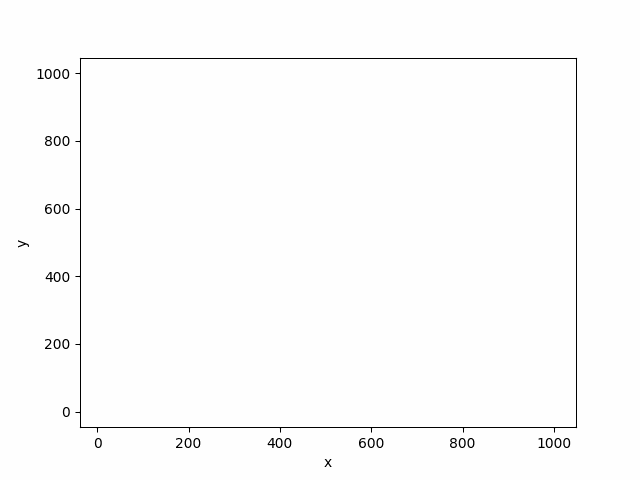

In [18]:
intersections,vis = find_intersections_with_visualization(section)
vis.show_gif()